<a href="https://colab.research.google.com/github/Nikolai-N484/Data201_NikolaiN/blob/main/Week9/DATA_201_Week_8b_Regularization_Coeff_Paths.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA 201 Week 8b: Regularization, Coefficient Paths, and Cross-Validation

This notebook is designed as an extension to the earlier Week 8a demo on **underfitting, good fit, and overfitting**.

If adds two new ideas:

1. **Regularization**: a way to control model complexity
2. **Cross-validation (CV)**: a way to choose a good amount of regularization

We will also add **coefficient path plots**, which show how model coefficients change as regularization gets stronger.



## Learning goals

By the end of this notebook, students should be able to:

- explain why regularization is used
- distinguish between **Ridge** and **Lasso** regularization
- interpret a **coefficient path plot**
- explain how **cross-validation** helps choose a hyperparameter
- connect regularization to **overfitting** and **underfitting**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(7)

## 1. Create a dataset with a curved relationship

We will generate a dataset where the true relationship is **curved**, not perfectly linear.

That matters because:

- a model that is too simple may miss the curve (**underfit**)
- a model that is too flexible may follow the random noise (**overfit**)

This gives us a setting where regularization is useful.

In [ ]:
# Create synthetic data
n = 120
X = np.sort(np.random.uniform(-3, 3, n))
noise = np.random.normal(0, 2.0, n)

def true_function(x):
    return 3 + 1.5*x - 0.8*(x**2) + 0.25*(x**3)

y = true_function(X) + noise

X = X.reshape(-1, 1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 90
Test set size: 30


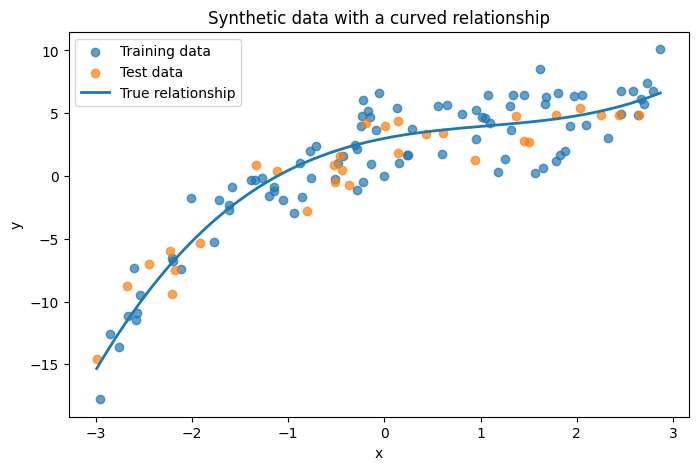

In [ ]:
# Plot the data
x_grid = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.7, label="Training data")
plt.scatter(X_test, y_test, alpha=0.7, label="Test data")
plt.plot(x_grid, true_function(x_grid.ravel()), linewidth=2, label="True relationship")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Synthetic data with a curved relationship")
plt.legend()
plt.show()

## 2. Reminder: underfitting and overfitting

Before regularization, let us quickly compare three polynomial regression models:

- degree 1: likely **too simple**
- degree 5: often a reasonable middle ground
- degree 15: flexible enough to risk **overfitting**

This provides the motivation for regularization.

In [ ]:
def polynomial_model(degree):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linreg", LinearRegression())
    ])

models = {
    "Degree 1": polynomial_model(1),
    "Degree 5": polynomial_model(5),
    "Degree 15": polynomial_model(15),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Test R^2": r2_score(y_test, y_test_pred)
    })

for row in results:
    print(row)

{'Model': 'Degree 1', 'Train RMSE': np.float64(2.9857868898823945), 'Test RMSE': np.float64(2.4962892373662497), 'Test R^2': 0.7664234310922255}
{'Model': 'Degree 5', 'Train RMSE': np.float64(1.886749447525313), 'Test RMSE': np.float64(1.7346449188657465), 'Test R^2': 0.8872125851036841}
{'Model': 'Degree 15', 'Train RMSE': np.float64(1.836617798991519), 'Test RMSE': np.float64(1.966134320221008), 'Test R^2': 0.8551008511541345}


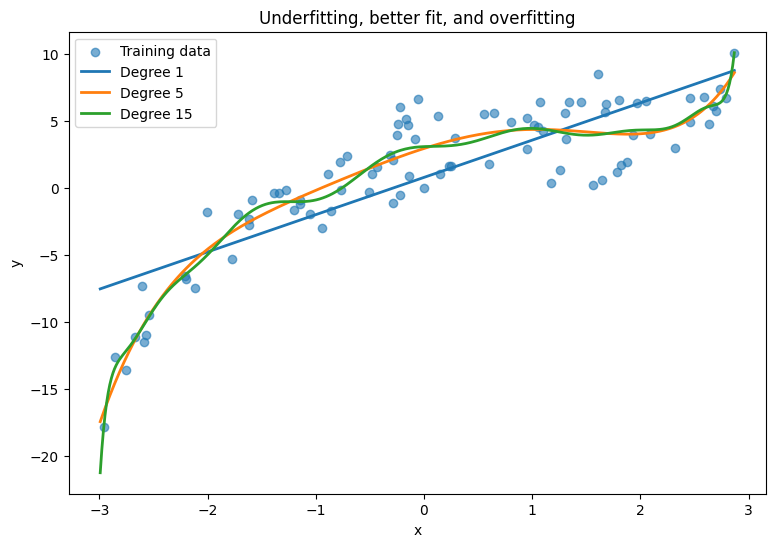

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(X_train, y_train, alpha=0.6, label="Training data")
colors = [None, None, None]

for name, model in models.items():
    model.fit(X_train, y_train)
    plt.plot(x_grid, model.predict(x_grid), linewidth=2, label=name)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Underfitting, better fit, and overfitting")
plt.legend()
plt.show()

### Discussion

The degree-15 model has many polynomial terms and can fit the training data very closely.
But that flexibility can become a problem: it may start fitting **noise** instead of the underlying pattern.

Regularization is one way to say:

> "Fit the data, but do not use unnecessarily large coefficients to do it."

## 3. What regularization does

For ordinary least squares regression, we minimize prediction error on the training data.

With regularization, we add a **penalty** for large coefficients.

### Ridge regression
Ridge adds a penalty based on the **squared size** of the coefficients.

- coefficients shrink toward zero
- usually none become exactly zero

### Lasso regression
Lasso adds a penalty based on the **absolute size** of the coefficients.

- coefficients shrink toward zero
- some may become exactly zero
- this can act like variable selection

The tuning parameter is usually called **alpha** in scikit-learn (many textbooks use **lambda**).

- small alpha: weak regularization
- large alpha: strong regularization

## 4. Fit high-degree polynomial models with Ridge and Lasso

To make regularization useful, we will intentionally create a model with many polynomial features.

Here we use a **degree-15 polynomial basis**. Without regularization, this model can easily overfit.

We also standardize the features because regularization methods are sensitive to scale.

In [ ]:
POLY_DEGREE = 15

ridge_demo = Pipeline([
    ("poly", PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

lasso_demo = Pipeline([
    ("poly", PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.05, max_iter=20000))
])

ols_demo = Pipeline([
    ("poly", PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linreg", LinearRegression())
])

for model_name, model in [("OLS", ols_demo), ("Ridge", ridge_demo), ("Lasso", lasso_demo)]:
    model.fit(X_train, y_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    print(f"{model_name:>5}  Train RMSE = {train_rmse:0.3f}   Test RMSE = {test_rmse:0.3f}")

  OLS  Train RMSE = 1.837   Test RMSE = 1.966
Ridge  Train RMSE = 1.890   Test RMSE = 1.737
Lasso  Train RMSE = 1.892   Test RMSE = 1.745


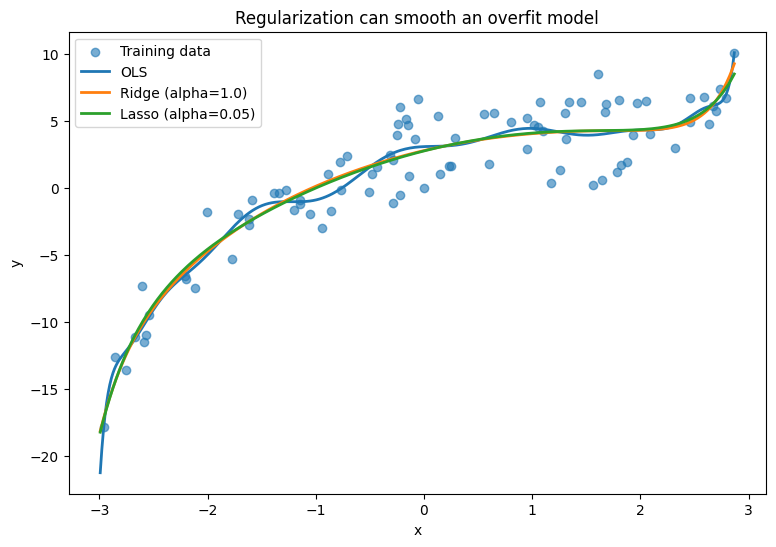

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(X_train, y_train, alpha=0.6, label="Training data")

for label, model in [("OLS", ols_demo), ("Ridge (alpha=1.0)", ridge_demo), ("Lasso (alpha=0.05)", lasso_demo)]:
    model.fit(X_train, y_train)
    plt.plot(x_grid, model.predict(x_grid), linewidth=2, label=label)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Regularization can smooth an overfit model")
plt.legend()
plt.show()

### Discussion

Notice the tradeoff:

- the unregularized high-degree model may fit the training data very closely
- Ridge and Lasso usually allow a slightly worse training fit
- but they often improve performance on new data

That is the central idea of regularization:

> accept a little more bias in exchange for lower variance and better generalization

## 5. Coefficient path plots

A **coefficient path plot** shows how each coefficient changes as the regularization strength changes.

- each line represents one coefficient
- the x-axis shows the value of **alpha**
- the y-axis shows the coefficient value

This plot helps students see that regularization is not just an abstract idea.
It literally **shrinks the coefficients**.

We will make separate path plots for Ridge and Lasso.

In [ ]:
# Build polynomial features once for coefficient path plots
poly = PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
feature_names = poly.get_feature_names_out(["x"])

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

alphas_ridge = np.logspace(-4, 3, 150)
alphas_lasso = np.logspace(-4, 1, 150)

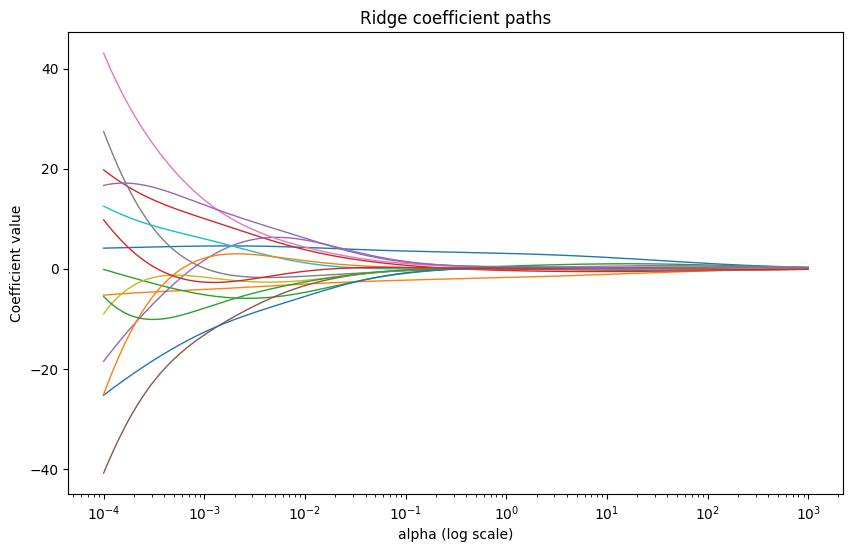

In [ ]:
# Ridge coefficient paths
ridge_coefs = []
for a in alphas_ridge:
    model = Ridge(alpha=a)
    model.fit(X_train_poly_scaled, y_train)
    ridge_coefs.append(model.coef_)

ridge_coefs = np.array(ridge_coefs)

plt.figure(figsize=(10, 6))
for j in range(ridge_coefs.shape[1]):
    plt.plot(alphas_ridge, ridge_coefs[:, j], linewidth=1)
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Coefficient value")
plt.title("Ridge coefficient paths")
plt.show()

### How to read the Ridge path

As **alpha** increases:

- coefficients are pulled toward zero
- the model becomes less flexible
- the fitted curve becomes smoother and usually more stable

In Ridge regression, coefficients usually get **small**, but not exactly zero.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.051e+01, tolerance: 2.618e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.549e+01, tolerance: 2.618e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.078e+01, tolerance: 2.618e

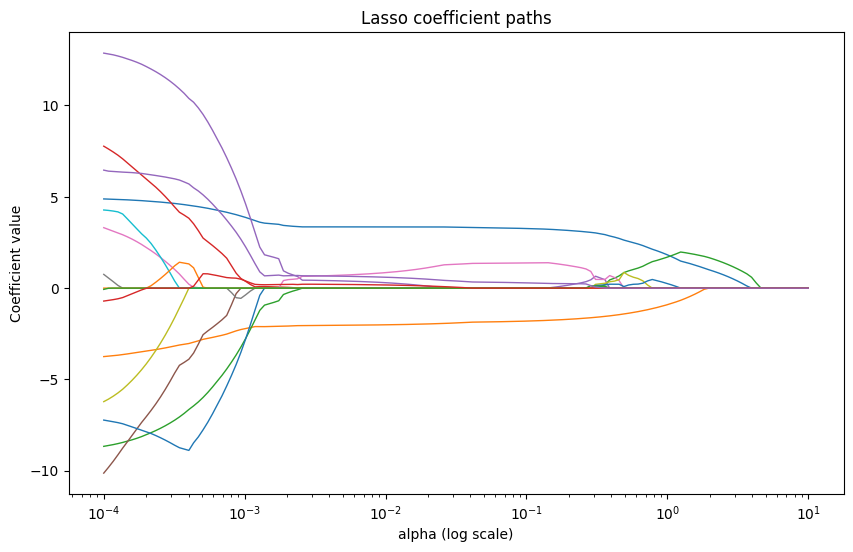

In [ ]:
# Lasso coefficient paths
lasso_coefs = []
for a in alphas_lasso:
    model = Lasso(alpha=a, max_iter=20000)
    model.fit(X_train_poly_scaled, y_train)
    lasso_coefs.append(model.coef_)

lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(10, 6))
for j in range(lasso_coefs.shape[1]):
    plt.plot(alphas_lasso, lasso_coefs[:, j], linewidth=1)
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Coefficient value")
plt.title("Lasso coefficient paths")
plt.show()

### How to read the Lasso path

As **alpha** increases:

- coefficients shrink toward zero
- some hit **exactly zero**
- the model may end up using fewer predictors

That makes Lasso especially useful when we want both:

- prediction
- a simpler model

## 6. Cross-validation to choose alpha

A coefficient path plot shows **what happens** as alpha changes.

But we still need to decide:

> Which alpha should we actually use?

This is where **cross-validation** comes in.

We will use CV only on the training data. The test set stays untouched until the very end.

In [ ]:
# Candidate alpha values
alpha_grid_ridge = np.logspace(-4, 3, 200)
alpha_grid_lasso = np.logspace(-4, 1, 200)

ridge_cv = Pipeline([
    ("poly", PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridgecv", RidgeCV(alphas=alpha_grid_ridge, cv=5))
])

lasso_cv = Pipeline([
    ("poly", PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)),
    ("scaler", StandardScaler()),
    ("lassocv", LassoCV(alphas=alpha_grid_lasso, cv=5, max_iter=20000, random_state=42))
])

ridge_cv.fit(X_train, y_train)
lasso_cv.fit(X_train, y_train)

best_alpha_ridge = ridge_cv.named_steps["ridgecv"].alpha_
best_alpha_lasso = lasso_cv.named_steps["lassocv"].alpha_

print(f"Best Ridge alpha from CV: {best_alpha_ridge}")
print(f"Best Lasso alpha from CV: {best_alpha_lasso}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.3213761616358397, tolerance: 0.2117449743049615
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.2817100597052331, tolerance: 0.2117449743049615
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.35174951236098195, tolerance: 0.2117449743049615
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Converg

Best Ridge alpha from CV: 2.4945081352303164
Best Lasso alpha from CV: 0.073168071434272


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6.165693227864978, tolerance: 0.2064583010535821
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 8.106831297028066, tolerance: 0.2064583010535821
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 9.99989531766991, tolerance: 0.2064583010535821
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceW

In [ ]:
# Evaluate final CV-selected models on the untouched test set
for label, model in [("Ridge CV", ridge_cv), ("Lasso CV", lasso_cv)]:
    train_rmse = np.sqrt(mean_squared_error(y_train, model.predict(X_train)))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    test_r2 = r2_score(y_test, model.predict(X_test))
    print(f"{label:>9}  Train RMSE = {train_rmse:0.3f}   Test RMSE = {test_rmse:0.3f}   Test R^2 = {test_r2:0.3f}")

 Ridge CV  Train RMSE = 1.899   Test RMSE = 1.736   Test R^2 = 0.887
 Lasso CV  Train RMSE = 1.893   Test RMSE = 1.728   Test R^2 = 0.888


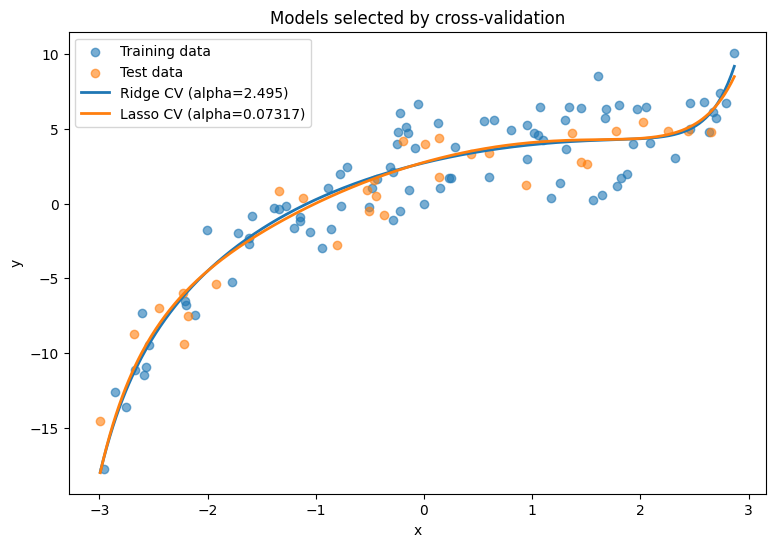

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(X_train, y_train, alpha=0.6, label="Training data")
plt.scatter(X_test, y_test, alpha=0.6, label="Test data")
plt.plot(x_grid, ridge_cv.predict(x_grid), linewidth=2, label=f"Ridge CV (alpha={best_alpha_ridge:0.4g})")
plt.plot(x_grid, lasso_cv.predict(x_grid), linewidth=2, label=f"Lasso CV (alpha={best_alpha_lasso:0.4g})")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Models selected by cross-validation")
plt.legend()
plt.show()

## 7. Put the CV-selected alpha on the coefficient path plot

This is the key connection:

- the coefficient path shows the **whole family of models**
- cross-validation picks **one point on that path**

So CV is a model-selection tool, and the path plot is a visualization of the options being considered.

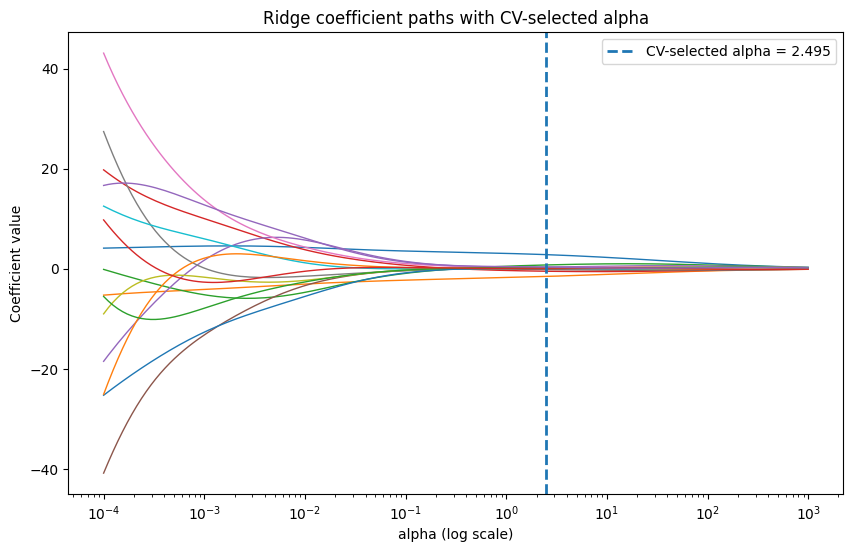

In [ ]:
plt.figure(figsize=(10, 6))
for j in range(ridge_coefs.shape[1]):
    plt.plot(alphas_ridge, ridge_coefs[:, j], linewidth=1)
plt.axvline(best_alpha_ridge, linestyle="--", linewidth=2, label=f"CV-selected alpha = {best_alpha_ridge:0.4g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Coefficient value")
plt.title("Ridge coefficient paths with CV-selected alpha")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
for j in range(lasso_coefs.shape[1]):
    plt.plot(alphas_lasso, lasso_coefs[:, j], linewidth=1)
plt.axvline(best_alpha_lasso, linestyle="--", linewidth=2, label=f"CV-selected alpha = {best_alpha_lasso:0.4g}")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("Coefficient value")
plt.title("Lasso coefficient paths with CV-selected alpha")
plt.legend()
plt.show()

## 8. Inspect the selected coefficients

It can also help students to look directly at the coefficients chosen by the final models.

This is especially interesting for Lasso, because some coefficients may be exactly zero.

In [ ]:
# Extract coefficients from final fitted models
ridge_final_coef = ridge_cv.named_steps["ridgecv"].coef_
lasso_final_coef = lasso_cv.named_steps["lassocv"].coef_

print("Ridge coefficients:")
for name, coef in zip(feature_names, ridge_final_coef):
    print(f"{name:>8}: {coef: .4f}")

print()
print("Lasso coefficients:")
for name, coef in zip(feature_names, lasso_final_coef):
    print(f"{name:>8}: {coef: .4f}")

Ridge coefficients:
       x:  2.8257
     x^2: -1.5349
     x^3:  0.7617
     x^4: -0.4955
     x^5:  0.3408
     x^6: -0.1517
     x^7:  0.2039
     x^8:  0.0164
     x^9:  0.1488
    x^10:  0.1027
    x^11:  0.1604
    x^12:  0.1376
    x^13:  0.2294
    x^14:  0.1366
    x^15:  0.3422

Lasso coefficients:
       x:  3.2877
     x^2: -1.8318
     x^3:  0.0000
     x^4: -0.0000
     x^5:  0.0000
     x^6: -0.0000
     x^7:  1.3687
     x^8: -0.0000
     x^9:  0.0000
    x^10: -0.0000
    x^11:  0.0000
    x^12:  0.0000
    x^13:  0.0000
    x^14:  0.0000
    x^15:  0.3094


## 9. Summary of the story

This notebook extends the earlier lesson in a natural way.

### Earlier lesson
- simple models can **underfit**
- flexible models can **overfit**
- train/test split helps us detect whether a model generalizes

### New lesson
- **regularization** controls model complexity
- a **coefficient path plot** shows how coefficients shrink as regularization increases
- **cross-validation** helps choose the best regularization strength

A concise way to say it:

> Regularization gives us a slider for model complexity.  
> Coefficient paths show what happens as we move the slider.  
> Cross-validation tells us where to stop.

## 10. Active learning exercise

This activity can be done individually, in pairs, or in small groups.

### Part A. Predict before running code
Look at the coefficient path plots and discuss:

1. What do you expect to happen when alpha becomes very small?
2. What do you expect to happen when alpha becomes very large?
3. Which method, Ridge or Lasso, is more likely to set coefficients exactly to zero?
4. Which method would you choose if you wanted a simpler model with fewer active predictors?

Write down your predictions before moving on.

### Part B. Modify the model complexity
Change the line

```python
POLY_DEGREE = 15
```

to one of the following values:

- 5
- 10
- 20

Then rerun the notebook from the point where `POLY_DEGREE` is defined.

Discuss:

1. How do the coefficient path plots change?
2. Does the CV-selected alpha change?
3. Does the test RMSE improve or get worse?
4. Does stronger regularization seem more important for higher-degree models?

### Part C. Compare weak and strong regularization
For Ridge and Lasso, manually try very different alpha values such as:

- 0.0001
- 0.01
- 0.1
- 1
- 10

For each value, record:

- training RMSE
- test RMSE
- what the fitted curve looks like

Then answer:

1. Which values seem to overfit?
2. Which values seem to underfit?
3. Which values seem to balance bias and variance best?

### Part D. Interpret the final model
Look at the final coefficients from the CV-selected Lasso model.

1. Which polynomial terms have coefficient 0?
2. Which terms remain important?
3. Does the final model seem easier to interpret than the full degree-15 polynomial?

### Reflection question
In 3-5 sentences, explain how these four ideas connect:

- overfitting
- regularization
- coefficient path plots
- cross-validation